<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [1]:
%pip install git+https://github.com/alemartinello/dstapi
%pip install fredapi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/pip-req-build-_qb8kz4u
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/pip-req-build-_qb8kz4u
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [3]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [5]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [6]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

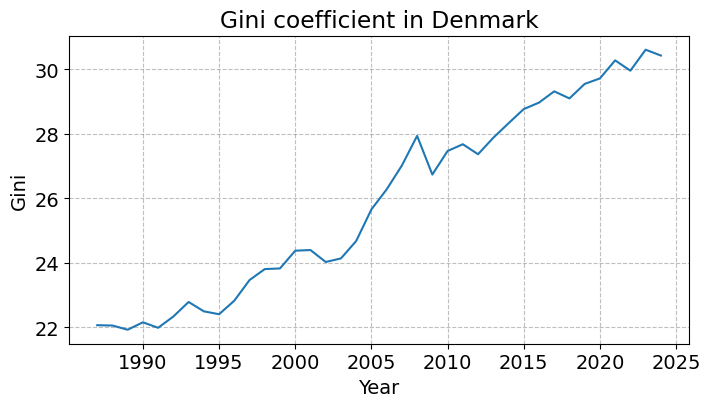

In [7]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [8]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [9]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [10]:
df=df.drop(columns=['KOMMUNEDK'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,DECILGEN,income
year,,
1987,First decil,31418
1987,Ninth decil,123582
1987,Eigth decil,110184
1987,Seventh decil,100691
1987,Sixth decil,92777


<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

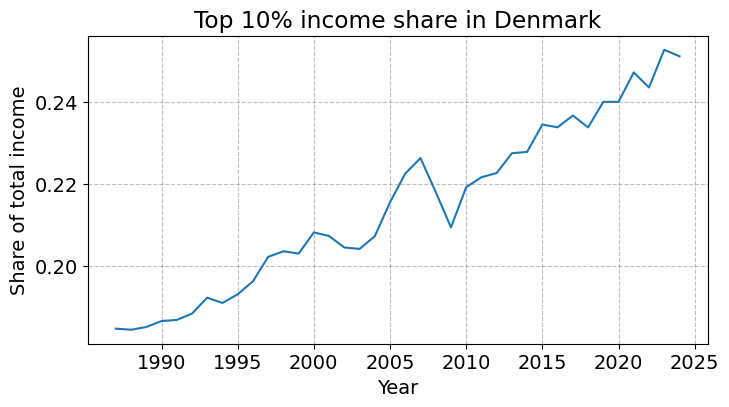

In [11]:
pivot = df.pivot_table(values='income', index=df.index, columns='DECILGEN', aggfunc='sum')
top10_share = pivot['Tenth decil'] / pivot.sum(axis=1)

top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

#Describe how inequality in Denmark has developed since 1987. Do the two measures
tell the same story? 

Both graphs show gradually increasing inequality from 1987 to 2000, a slight dip from 2000 to ~2003 followed by a sharp spike that peaked immediately before the financial crisis and sharply fell during it, before continuing on its previous trend of gradually increasing from 2010-2024.


In [12]:
#Compute the correlation between them over time
np.corrcoef(ginidk['gini'].astype(float), top10_share)[0,1]



np.float64(0.9816415450527721)

### 1.2 Prediction

In [13]:
# Importing the packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [14]:
# Setting up the prediction

y= ginidk['gini'].astype(float).values
t = ginidk.index.astype(int).values - 1987
t = t.astype(float)

S1 = lambda beta: sum((y-(beta[0] + beta[1]*t))**2)
S2 = lambda beta: sum((y-(beta[0] + beta[1]*t+beta[2]*t**2))**2)


In [15]:
# Solving the minimization problem

minproblin= minimize(S1, x0=(0,0), constraints=None)
minprobqua= minimize(S2, x0=(0,0,0), constraints=None)

beta0_lin, beta1_lin = minproblin.x
beta0_quad, beta1_quad, beta2_quad = minprobqua.x

print("beta linear=", beta0_lin, beta1_lin)
print("beta quadratic=", beta0_quad, beta1_quad, beta2_quad)

beta linear= 21.042753545648125 0.26354959467635763
beta quadratic= 21.304186697307134 0.21997579816762736 0.0011776761712922607


In [16]:
# Checking the answes against np.polyfit

coeff_lin = np.polyfit(t,y,1)
print(coeff_lin)

coeff_quad= np.polyfit(t,y,2)
print(coeff_quad)

[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


Text(0, 0.5, 'Gini')

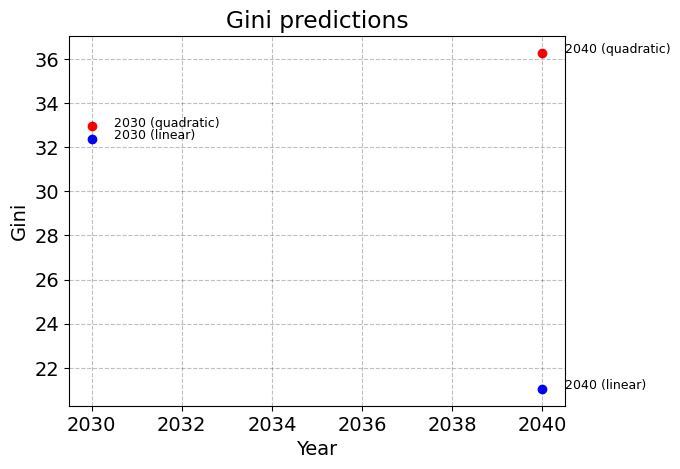

In [17]:
# Predicting and plotting the Gini coefficient in 2030 and 2040
t2030=2030-1987
t2040=2040-1987

"""
To find y, I set y to the formula S1 and S2 because the difference between them should be 0 if the formula is correctly minimized.
"""
lin_gin2030 = beta0_lin + beta1_lin*t2030
lin_gin2040 = beta0_lin + beta1_lin**t2040
quad_gin2030= beta0_quad + beta1_quad*t2030+beta2_quad*t2030**2
quad_gin2040= beta0_quad + beta1_quad*t2040+beta2_quad*t2040**2

plt.scatter(2030, lin_gin2030, color='blue')
plt.text(2030 + 0.5, lin_gin2030 + 0.001, '2030 (linear)', fontsize=9)

plt.scatter(2040, lin_gin2040, color='blue')
plt.text(2040 + 0.5, lin_gin2040 + 0.001, '2040 (linear)', fontsize=9)

plt.scatter(2030, quad_gin2030, color='red')
plt.text(2030 + 0.5, quad_gin2030 + 0.001, '2030 (quadratic)', fontsize=9)

plt.scatter(2040, quad_gin2040, color='red')
plt.text(2040 + 0.5, quad_gin2040 + 0.001, '2040 (quadratic)', fontsize=9)

plt.title('Gini predictions')
plt.xlabel('Year')
plt.ylabel('Gini')

Explaining the graph:
...

### 1.3 Municipalities

#### 1.3.1

In [ ]:
IFOR41.tablesummary(language='en')

In [ ]:
#Gini across municipalities

params_muni_gini = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_gini = IFOR41.get_data(params=params_muni_gini)
municip_gini.head(5)

In [ ]:
# Clearing the data

municip_gini=municip_gini.drop(columns=['ULLIG',])
municip_gini = municip_gini.rename(columns={'INDHOLD':'gini', 'TID': 'year','KOMMUNEDK':'municipalities'})
municip_gini= municip_gini.set_index('year').sort_index()

display(municip_gini)

In [ ]:
IFOR32.tablesummary(language='en')

In [ ]:
# Top 10 share across municipalities

params_muni_top10 = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_top10 = IFOR32.get_data(params=params_muni_top10)
display(municip_top10)

In [ ]:
# Clearing the data

municip_top10 = municip_top10.rename(columns={'INDHOLD':'income', 'TID': 'year','KOMMUNEDK':'municipalities'})
municip_top10= municip_top10.set_index('year').sort_index()

municip_top10.head(5)

In [ ]:
municip_top10_reset = municip_top10.reset_index()

pivot_muni = municip_top10_reset.pivot_table(
    values='income',
    index=['year', 'municipalities'],
    columns='DECILGEN',
    aggfunc='sum'
)

municip_top10_share = pivot_muni['Tenth decil'] / pivot.sum(axis=1)

display(municip_top10_share)

In [ ]:
# Merging the two tables 

combined = pd.merge(
    municip_gini.reset_index(),
    municip_top10_share.reset_index(name='top10_share'),
    on=['year', 'municipalities'],
    how='inner'
)

combined = combined.sort_values(['municipalities', 'year']).reset_index(drop=True)

display(combined)

In [ ]:
# Setting the type

combined['gini'] = combined['gini'].astype(float)
combined['top10_share'] = combined['top10_share'].astype(float)

In [ ]:
# Using groupby to find year-to-year differences

combined[['diff_gini','diff_top10_share']] = combined.groupby('municipalities')[['gini','top10_share']].diff()
combined.head(20)

In [ ]:
# Printing the mean of the correlation

corr=combined.groupby('municipalities')['diff_gini'].corr(combined['diff_top10_share']).rename('correlation')
mean_correlation=corr.mean()
print(f'{mean_correlation = :.3f}')

In [ ]:
# Sorting the values

corr = corr.sort_values()
print(corr)

In [ ]:
# Plotting the correlation

fig, ax = plt.subplots(figsize=(6, 12))

ax.barh(corr.index, corr.values,height=0.5, color='lightblue')


ax.axvline(mean_correlation,color='darkblue',linestyle='--',linewidth=1.2,label=f'Mean = {mean_correlation:.2f}')

ax.set_xlabel('Correlation',fontsize=12)

ax.set_yticks(range(len(corr.index)))
ax.set_yticks(np.arange(len(corr.index))*1)
ax.set_yticklabels(corr.index,fontsize=8)
ax.set_ylim(-0.5,len(corr.index)-0.5)


ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


fig.suptitle('Correlation of ginicoefficient and top 10% income share',fontsize=14)
fig.tight_layout()

#### 1.3.2

In [ ]:
#Sorting gini for 2024
gini_2024 = municip_gini.loc[2024].sort_values('gini')

#Finding the smallest and largest gini coefficients
smallest_gini = gini_2024[['municipalities', 'gini']].head(10)
largest_gini = gini_2024[['municipalities', 'gini']].tail(10)

print("10 most equal municipalities: ", smallest_gini)
print("10 most unequal municipalities: ", largest_gini)

KeyError: "['KOMMUNEDK'] not in index"

#### 1.3.3

In [ ]:

municip_gini3 = municip_gini.reset_index()
gini_2024 = municip_gini3[municip_gini3['year'] == 2024][['municipalities', 'gini']].rename(columns={'gini': 'gini_2024'})
gini_1987 = municip_gini3[municip_gini3['year'] == 1987][['municipalities', 'gini']].rename(columns={'gini': 'gini_1987'})

gini_change = gini_2024.merge(gini_1987, on='municipalities', how='inner')


gini_change['gini_change'] = gini_change['gini_2024'].astype(float) - gini_change['gini_1987'].astype(float)

gini_change_sorted = gini_change.sort_values('gini_change', ascending=False)


# Biggest change
print("Biggest change in Gini: ", gini_change_sorted.head(10))

# Smallest change
print("Smallest change in Gini", gini_change.sort_values('gini_change', ascending=True).head(10))

Biggest change in Gini:      municipalities gini_2024 gini_1987  gini_change
7            Vejen     46.32     21.20        25.12
74       Rudersdal     47.31     29.05        18.26
64        Gentofte     49.04     31.10        17.94
57  Lyngby-Taarbæk     39.28     24.97        14.31
69      Copenhagen     34.97     23.05        11.92
73        Hørsholm     40.07     28.39        11.68
50     Fredensborg     32.76     21.17        11.59
39          Aarhus     33.43     22.10        11.33
68   Frederiksberg     36.54     25.28        11.26
53      Vallensbæk     26.70     15.90        10.80
Smallest change in Gini      municipalities gini_2024 gini_1987  gini_change
9              Fanø     26.34     25.67         0.67
15              Ærø     26.98     24.63         2.35
97             Faxe     24.09     21.64         2.45
28             Læsø     25.41     22.81         2.60
75         Bornholm     24.03     21.31         2.72
48  Faaborg-Midtfyn     23.77     20.88         2.89
81      

### 1.4 Extension

We want to analyse the correlation between the gini coefficient and unemployment

In [ ]:
# Using table AULP01 for this task - importing the data

AULP01 = DstApi('AULP01') 

AULP01.tablesummary(language='en')

Table AULP01: Full-time unemployed persons in per cent of the labour force by region, age, sex and time
Last update: 2026-04-14T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,117,000,All Denmark,997,Abroad,False
1,ALDER,10,TOT,"Age, total",6099,60 year and over,False
2,KØN,3,TOT,Total,K,Women,False
3,Tid,19,2007,2007,2025,2025,True


In [ ]:
# Setting up the table for AULP01

params = {
    'table': 'AULP01',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']}, 
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

unemployment = AULP01.get_data(params=params)
unemployment.head(5)

,OMRÅDE,ALDER,KØN,TID,INDHOLD
0,All Denmark,"Age, total",Total,2013,5.8
1,Province Byen København,"Age, total",Total,2013,6.9
2,Province Københavns omegn,"Age, total",Total,2013,5.9
3,Province Nordsjælland,"Age, total",Total,2013,4.4
4,Province Bornholm,"Age, total",Total,2013,7.0


In [ ]:
# Cleaning it up

unemployment=unemployment.drop(columns=['ALDER','KØN'])
unemployment = unemployment.rename(columns={'INDHOLD':'unemployment', 'OMRÅDE': 'municipality', 'TID': 'year'})
unemployment= unemployment.set_index('year').sort_index()

display(unemployment)

,municipality,unemployment
year,,
2007,Ringsted,3.1
2007,Vejen,1.9
2007,Aabenraa,3.8
2007,Fredericia,3.3
2007,Horsens,2.3
...,...,...
2025,Svendborg,2.9
2025,Odense,3.8
2025,Nyborg,3.2


In [ ]:
# Sorting in alphabetic order

unemployment = unemployment.reset_index().sort_values(['year','municipality']).reset_index(drop=True) 
display(unemployment)

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
4,2007,All Denmark,3.6
...,...,...,...
2180,2025,Vejle,2.4
2181,2025,Vesthimmerlands,2.6
2182,2025,Viborg,2.5
2183,2025,Vordingborg,2.9


In [ ]:
# Dropping rows

drop_rows = unemployment.municipality.str.contains('Region')
drop_rows  |= unemployment.municipality.str.contains('Province')
drop_rows |= unemployment.municipality.str.contains('All Denmark')
drop_rows |= unemployment.year==2025
unemployment.loc[~drop_rows,:]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6
...,...,...,...
2065,2024,Vejle,2.6
2066,2024,Vesthimmerlands,2.9
2067,2024,Viborg,2.7
2068,2024,Vordingborg,3.0


In [ ]:
# Saving the result

unemployment= unemployment.loc[drop_rows==False] 
unemployment.iloc[:5,:5]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6


In [ ]:
# Using table IFOR41 for the gini coefficient
# Resetting index to use for this task

municip_gini4 = municip_gini.reset_index()

display(municip_gini4)

,year,municipalities,gini
0,1987,Hjørring,21.96
1,1987,Greve,18.64
2,1987,Køge,19.52
3,1987,Halsnæs,18.50
4,1987,Roskilde,20.54
...,...,...,...
3757,2024,Greve,26.35
3758,2024,Frederikssund,26.11
3759,2024,Egedal,23.85
3760,2024,Faxe,24.09


In [ ]:
# Dropping rows

drop_rows = municip_gini4.year.between(1987,2006)
drop_rows |= municip_gini4.municipalities.str.contains('All Denmark')
municip_gini5=municip_gini4.loc[~drop_rows,:]
display(municip_gini5)

,year,municipalities,gini
1980,2007,Odsherred,23.21
1981,2007,Egedal,21.07
1982,2007,Frederikssund,23.47
1983,2007,Greve,24.48
1984,2007,Køge,22.85
...,...,...,...
3757,2024,Greve,26.35
3758,2024,Frederikssund,26.11
3759,2024,Egedal,23.85
3760,2024,Faxe,24.09


In [ ]:
# Merging the two tables

unemployment2 = unemployment.rename(columns={'municipality': 'municipalities'})

combined1 = pd.merge(
    unemployment2.reset_index(drop=True),
    municip_gini5.reset_index(drop=True),
    on=['year', 'municipalities'],
    how='inner'
)

combined1 = combined1.sort_values(['municipalities', 'year']).reset_index(drop=True)

display(combined1)

,year,municipalities,unemployment,gini
0,2007,Aabenraa,3.8,25.36
1,2008,Aabenraa,2.8,26.88
2,2009,Aabenraa,5.2,25.57
3,2010,Aabenraa,6.8,25.09
4,2011,Aabenraa,6.4,25.01
...,...,...,...,...
1759,2020,Ærø,4.0,25.61
1760,2021,Ærø,3.1,26.63
1761,2022,Ærø,1.8,27.02
1762,2023,Ærø,1.9,27.67


In [ ]:
# Setting the type

combined1['unemployment'] = combined1['unemployment'].astype(float)
combined1['gini'] = combined1['gini'].astype(float)

In [ ]:
# Using groupby to find year-to-year differences

combined1[['diff_unemployment','diff_gini']] = combined1.groupby('municipalities')[['unemployment','gini']].diff()
combined1.head(20)

,year,municipalities,unemployment,gini,diff_unemployment,diff_gini
0,2007,Aabenraa,3.8,25.36,NaN,NaN
1,2008,Aabenraa,2.8,26.88,-1.0,1.52
2,2009,Aabenraa,5.2,25.57,2.4,-1.31
3,2010,Aabenraa,6.8,25.09,1.6,-0.48
4,2011,Aabenraa,6.4,25.01,-0.4,-0.08
5,2012,Aabenraa,6.9,24.83,0.5,-0.18
6,2013,Aabenraa,6.4,25.36,-0.5,0.53
7,2014,Aabenraa,5.2,27.42,-1.2,2.06
8,2015,Aabenraa,4.7,25.27,-0.5,-2.15
9,2016,Aabenraa,4.0,25.38,-0.7,0.11


In [ ]:
# Printing the mean of the correlation

corr1=combined1.groupby('municipalities')['diff_unemployment'].corr(combined1['diff_gini']).rename('correlation1')
mean_correlation1=corr1.mean()
print(f'{mean_correlation1 = :.3f}')

mean_correlation1 = -0.198


In [ ]:
# Sorting the values

corr1 = corr1.sort_values()
print(corr1)

municipalities
Kalundborg    -0.725965
Rebild        -0.693818
Norddjurs     -0.681937
Brønderslev   -0.656554
Assens        -0.644497
                 ...   
Læsø           0.301239
Brøndby        0.372060
Glostrup       0.524221
Hvidovre       0.598075
Albertslund    0.824240
Name: correlation1, Length: 98, dtype: float64


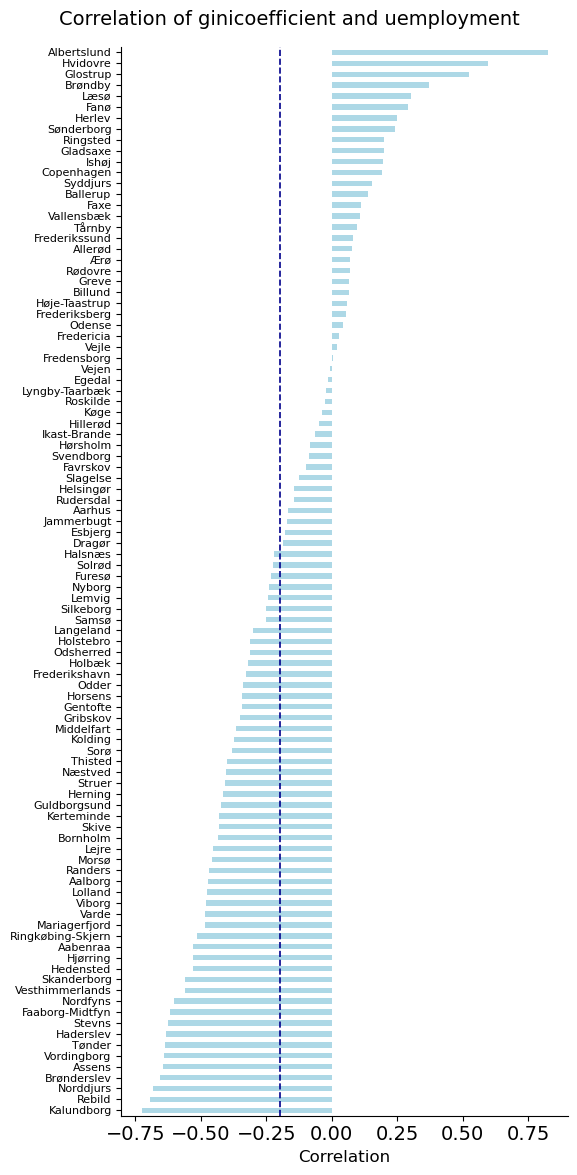

In [ ]:
# Plotting the correlation

fig, ax = plt.subplots(figsize=(6, 12))

ax.barh(corr1.index, corr1.values,height=0.5, color='lightblue')


ax.axvline(mean_correlation1,color='darkblue',linestyle='--',linewidth=1.2,label=f'Mean = {mean_correlation1:.2f}')

ax.set_xlabel('Correlation',fontsize=12)

ax.set_yticks(range(len(corr1.index)))
ax.set_yticks(np.arange(len(corr1.index))*1)
ax.set_yticklabels(corr1.index,fontsize=8)
ax.set_ylim(-0.5,len(corr1.index)-0.5)


ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


fig.suptitle('Correlation of ginicoefficient and uemployment',fontsize=14)
fig.tight_layout()

We see a small positive correlition between year to year changes in uenmployment and year to year changes in gini.

<h2> 2 Simulating the income distribution

### 2.1 The model

In [ ]:
import pickle
import numpy as np

from scipy.stats import norm 

In [ ]:
from income_simulation import simulate_income_distribution
from Gini import gini


N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123

result = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)


ages = result['ages']
income = result['income']      
employed = result['employed']
e = result['education']

print(result) ##need to make prettier

#Check that the mean is one for the lognormal shock psi
rng_check = np.random.default_rng(seed)
psi_check = rng_check.lognormal(-0.5 * sigma_psi**2, sigma_psi, size=1_000_000)

print(f'Mean of psi: {psi_check.mean():.4f}')  # should be equal or close to 1.0

### 2.2 Simulate the income distribution

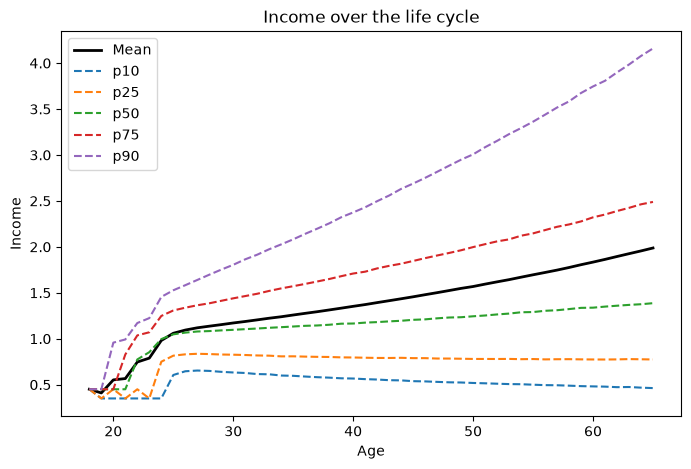

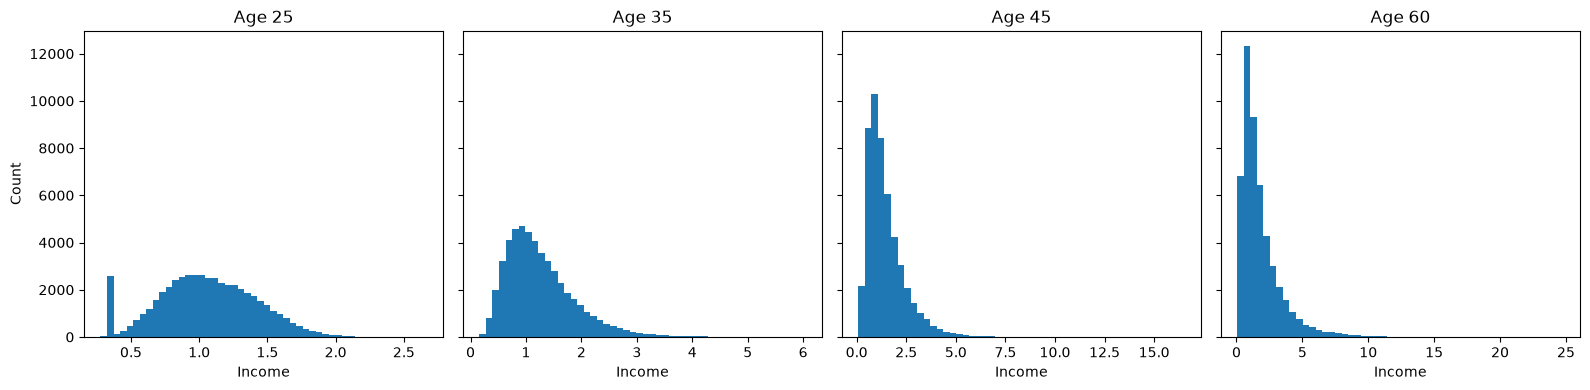

In [ ]:

# Mean and selected percentiles of income over the life cycle

percentiles = [10, 25, 50, 75, 90]
income_percentiles = np.percentile(income, percentiles, axis=0)  # shape (5, T)
income_mean = income.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, income_mean, label='Mean', linewidth=2, color='black')
for p, series in zip(percentiles, income_percentiles):
    ax.plot(ages, series, label=f'p{p}', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()
plt.show()

# Histograms of the income distribution at selected ages
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, age in zip(axes, [25, 35, 45, 60]):
    idx = age - age_min  # column index for this age
    ax.hist(income[:, idx], bins=50)
    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
axes[0].set_ylabel('Count')
fig.tight_layout()
plt.show()



### 2.3 Compute the Gini coefficient

### 2.4 What drives inequality?

### 2.5 Extension: more risk